In [1]:
from set_up.generic_business_case_runner import run_business_case

from assets.EL_input_data import el_parameters
from assets.OWF_input_data import owf_parameters
from assets.OnEL_input_data import onel_parameters
from assets.OT_input_data import ot_parameters, ot_parameter_update

import ipynb.fs.defs.assets.EL_working_file as el_module
import ipynb.fs.defs.assets.OWF_working_file as owf_module
import ipynb.fs.defs.assets.OnEL_working_file as onel_module
import ipynb.fs.defs.assets.OT_working_file as ot_module

import assets.EL_input_data as el_inputs
import assets.OWF_input_data as owf_inputs
import assets.OnEL_input_data as onel_inputs
import assets.OT_input_data as ot_inputs

import set_up.generic_business_case_runner as runner

from analysis.sensitivity import run_oat_sensitivity,get_base_case_values,tornado_plot
from analysis.cum_equity_debt_figure import plot_cumulative_cashflows
from analysis.scenario_analysis import run_levelized_breakdown_scenarios, plot_scenario_breakdown

Active Scenario: most_likely (Index: 1)
Active Scenario: most_likely (Index: 1)
Active Scenario: most_likely (Index: 1)
Active Scenario: most_likely (Index: 1)
loading cached data from profiles.pkl...
All variables saved to NSE_get_data_from_ESDL.pkl


**Sensitivity analysis**

In [2]:
# Run the sensitivity analysis, this will give 4 KPI dfs
df_proj_npv_sa, df_eq_npv_sa, df_lco_sa, df_gap_sa = run_oat_sensitivity(ot_module, runner, ot_parameters,ot_parameter_update)

# View all tables
print("--- 1) PROJECT NPV SENSITIVITY ---")
display(df_proj_npv_sa.style.format(precision=2))

print("\n--- 2) EQUITY NPV SENSITIVITY ---")
display(df_eq_npv_sa.style.format(precision=2))

print("\n--- 3) LEVELIZED COST SENSITIVITY ---")
display(df_lco_sa.style.format(precision=2))

print("\n--- 4) UNPROFITABLE GAP SENSITIVITY ---")
display(df_gap_sa.style.format(precision=2))

--- 1) PROJECT NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-36.74,-23.83
ng_boiler_lifetime,-30.74,-30.74
wacc,-30.36,-30.90
income_tax_rate,-30.74,-30.74
inflation,-30.82,-30.66
loan_interest_rate,-30.74,-30.74
loan_percentage,-30.74,-30.74
length_of_loan,-30.74,-30.74
h2_boiler_decommissioning_percentage,-30.74,-30.74



--- 2) EQUITY NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-27.58,-17.95
ng_boiler_lifetime,-23.10,-23.10
wacc,-23.11,-22.96
income_tax_rate,-23.81,-22.40
inflation,-23.16,-23.04
loan_interest_rate,-22.87,-23.34
loan_percentage,-23.37,-22.83
length_of_loan,-23.28,-22.94
h2_boiler_decommissioning_percentage,-23.10,-23.10



--- 3) LEVELIZED COST SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,224.90,227.53
ng_boiler_lifetime,226.33,226.33
wacc,226.97,225.73
income_tax_rate,226.33,226.33
inflation,222.75,229.98
loan_interest_rate,226.09,226.58
loan_percentage,226.10,226.56
length_of_loan,226.19,226.47
h2_boiler_decommissioning_percentage,226.33,226.33



--- 4) UNPROFITABLE GAP SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-117.75,-113.25
ng_boiler_lifetime,-115.60,-115.60
wacc,-115.12,-116.07
income_tax_rate,-116.05,-115.15
inflation,-113.93,-117.31
loan_interest_rate,-115.42,-115.79
loan_percentage,-115.44,-115.77
length_of_loan,-115.50,-115.71
h2_boiler_decommissioning_percentage,-115.60,-115.60


Tornado graphs

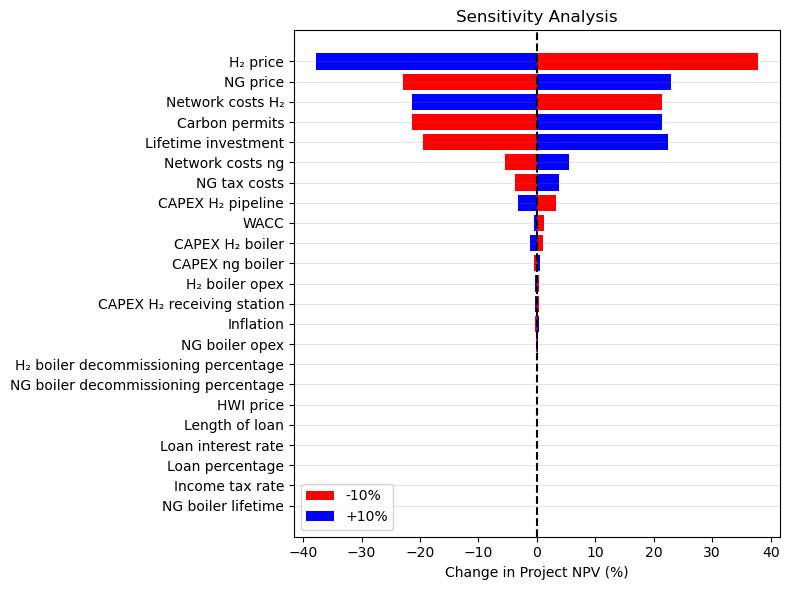

In [3]:
# First we get the base case values
owf_base_cases = get_base_case_values(owf_module, runner, owf_parameters)
el_base_cases = get_base_case_values(el_module, runner, el_parameters)
onel_base_cases = get_base_case_values(onel_module, runner, onel_parameters)
ot_base_cases = get_base_case_values(ot_module, runner, ot_parameters)

# Plot the Project NPV tornado graph 
tornado_plot(df_proj_npv_sa,ot_base_cases['Project NPV'],'Project NPV')

# Plot the Equity NPV tornado graph 
# tornado_plot(df_eq_npv_sa,el_base_cases['Equity NPV'], 'Equity NPV')

# Plot the Levelized Cost tornado graph
# tornado_plot(df_lco_sa, el_base_cases['Levelized Cost'], 'Levelized Cost')

# Plot the Unprofitable Gap tornado graph
# tornado_plot(df_gap_sa,el_base_cases['Unprofitable Gap'], 'Unprofitable Gap')

Cumulative equity and debt figure

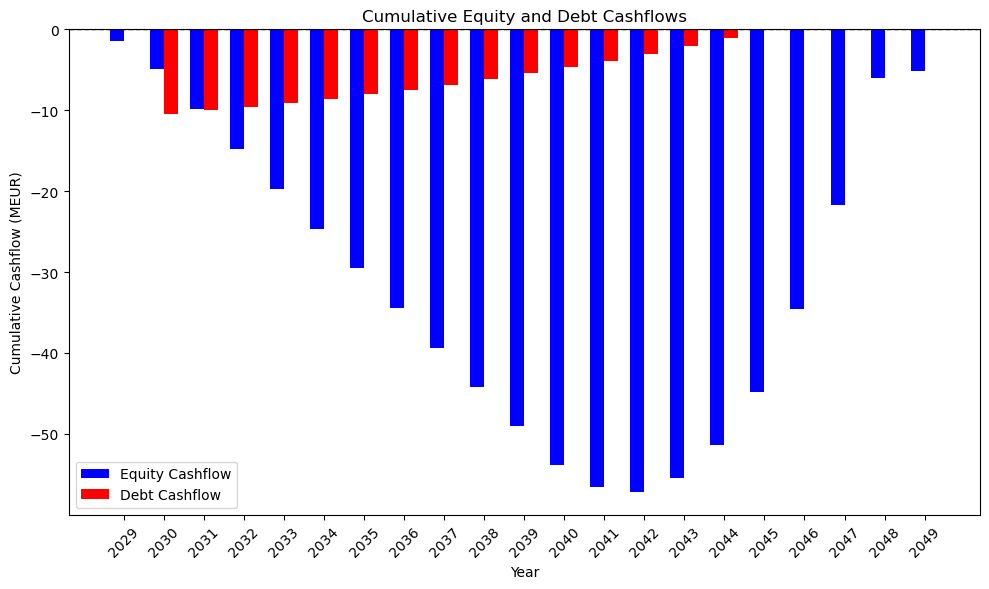

In [4]:
# Plot the graph
plot_cumulative_cashflows(ot_module, runner, ot_parameters)

**Pessimistic, most likely, optimistic scenarios**

In [5]:
# Get the df with levelized cost and revenues for all scenarios
df_analysis = run_levelized_breakdown_scenarios(runner, ot_module, ot_inputs, "ot_parameters")
display(df_analysis.style.format(precision=2))

Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


levelized cost calculations,Cost (Pessimistic),Revenue (Pessimistic),Cost (Base),Revenue (Base),Cost (Optimistic),Revenue (Optimistic)
capex_h2_boiler,2.35,0.00,2.18,0.00,1.99,0.00
capex_h2_station,0.62,0.00,0.58,0.00,0.53,0.00
capex_h2_pipeline,8.24,0.00,6.25,0.00,4.38,0.00
avoided_capex_ng_boiler,0.00,1.07,0.00,0.99,0.00,0.90
h2_boiler_opex,0.63,0.00,0.64,0.00,0.66,0.00
network_costs_h2,54.77,0.00,41.94,0.00,28.67,0.00
purchasing_h2,75.73,0.00,74.21,0.00,68.60,0.00
purchasing_hwi,95.58,0.00,97.46,0.00,101.03,0.00
avoided_ng_boiler_opex,0.00,0.28,0.00,0.38,0.00,0.48
network_costs_ng,0.00,10.56,0.00,10.73,0.00,11.05


Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


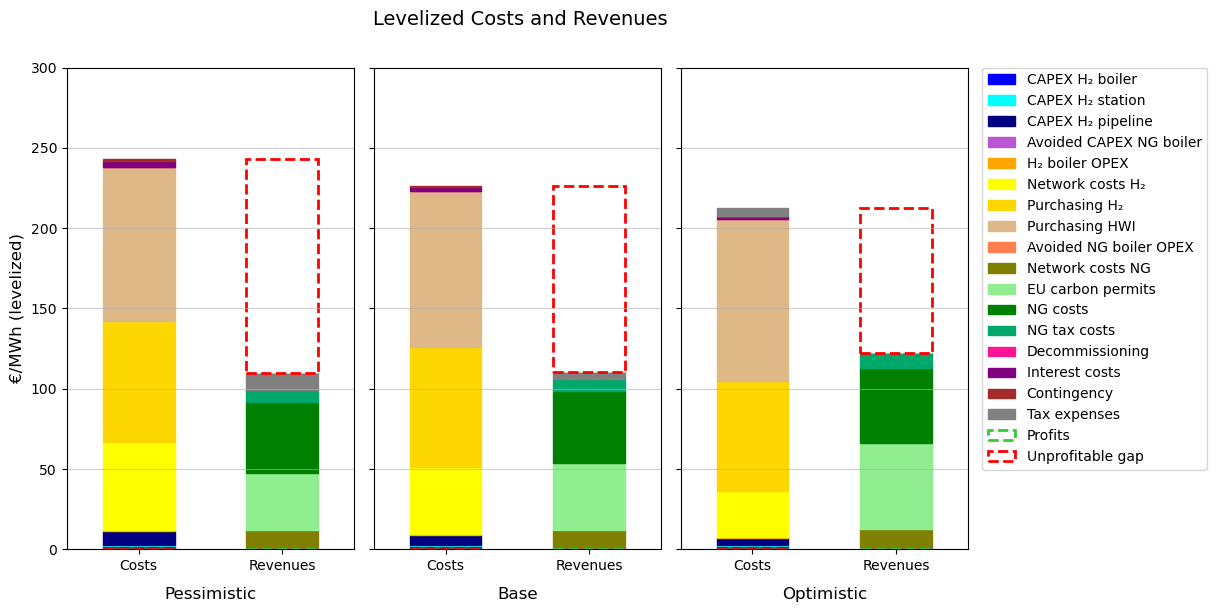

In [6]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, ot_module, ot_inputs, "ot_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')

Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


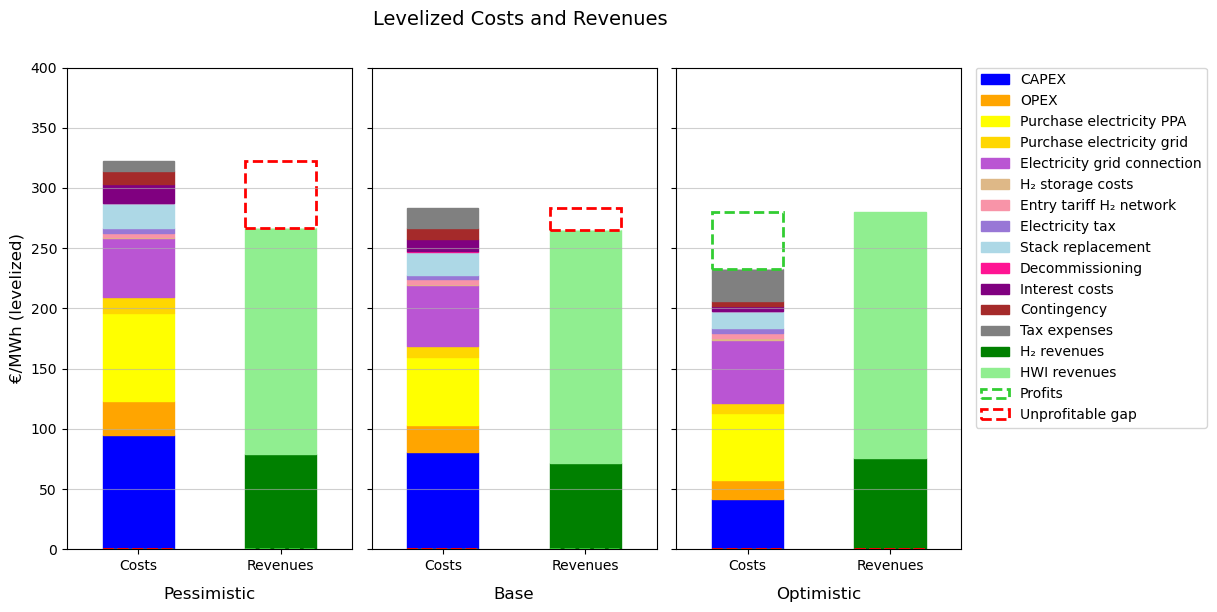

In [7]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, onel_module, onel_inputs, "onel_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')


Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


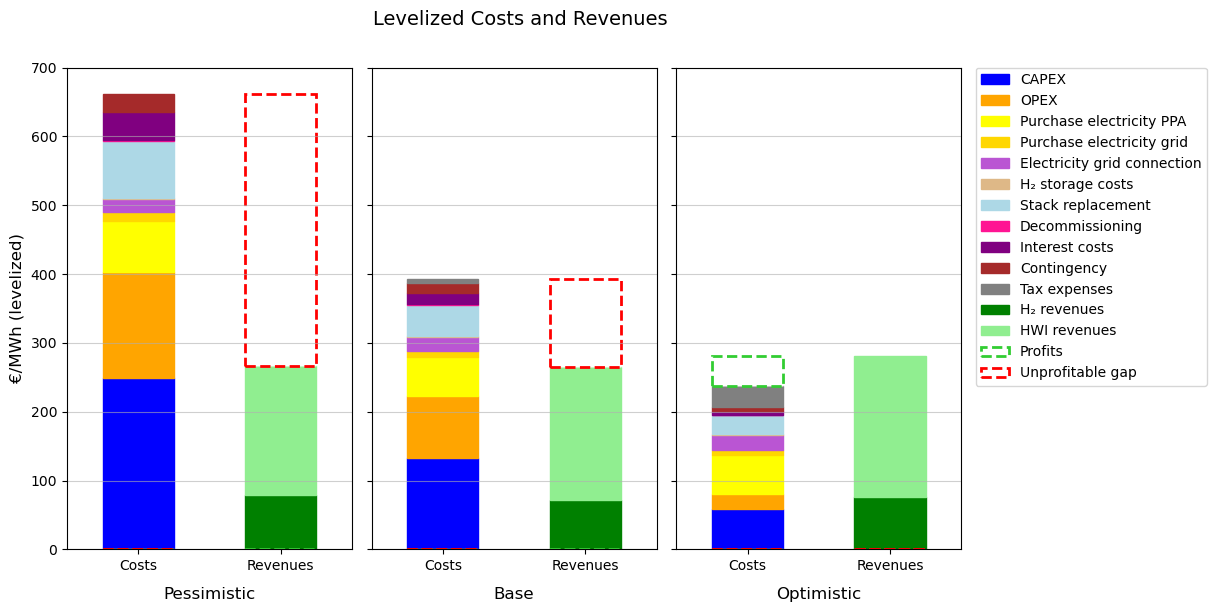

In [8]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, el_module, el_inputs, "el_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')

Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


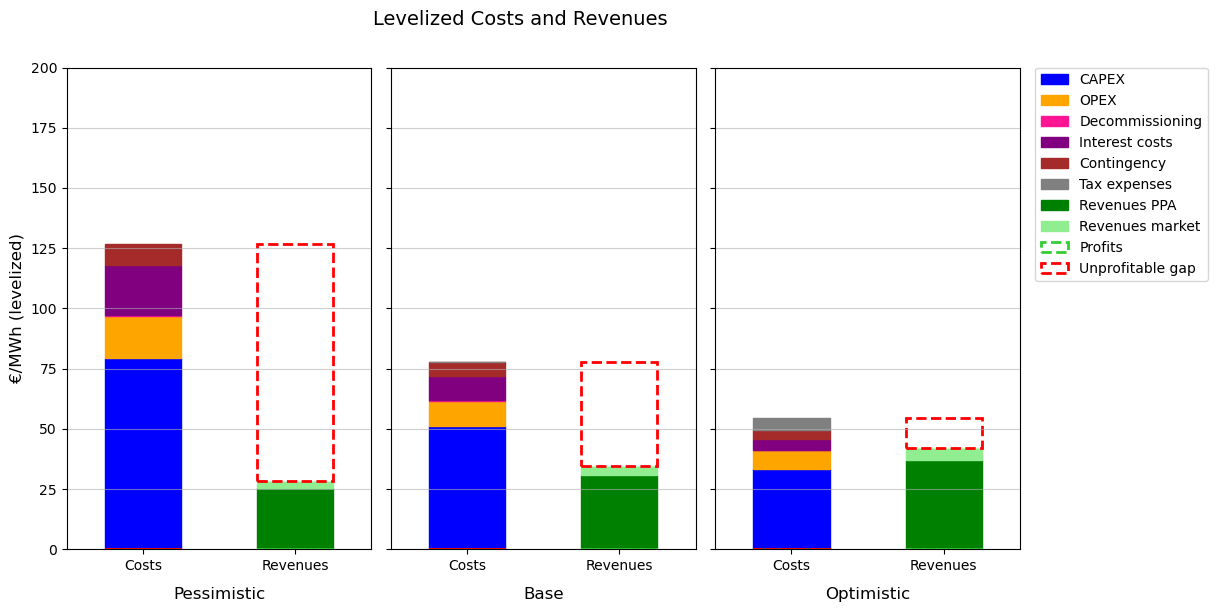

In [9]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, owf_module, owf_inputs, "owf_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')